<a href="https://colab.research.google.com/github/zyf-hitsz/PytorchLearning/blob/main/%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C/%E5%8D%B7%E7%A7%AF%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C/LetNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#卷积神经网络

##LetNet
LetNet是最早发布的神经网络之一，主要用于计算机视觉任务。
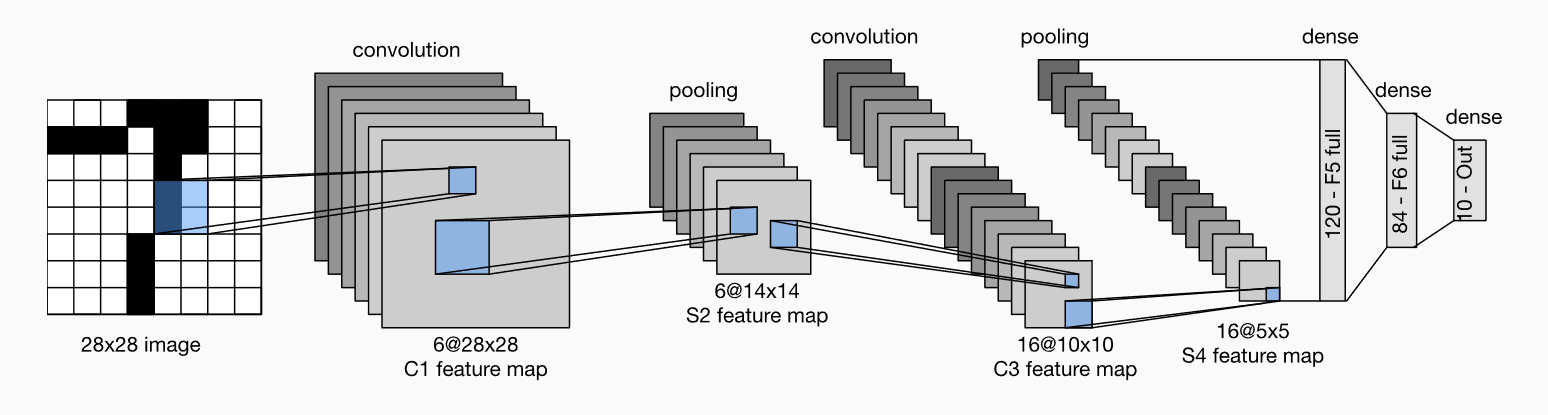

每个卷积块中的基本单元是一个卷积层、一个sigmoid激活函数和平均池化层。虽然ReLU和最大汇聚层更有效，但它们在20世纪90年代还没有出现。

LetNet的结构可以简记为：
```
Conv → Pool → Conv → Pool → Conv → FC → Output
```
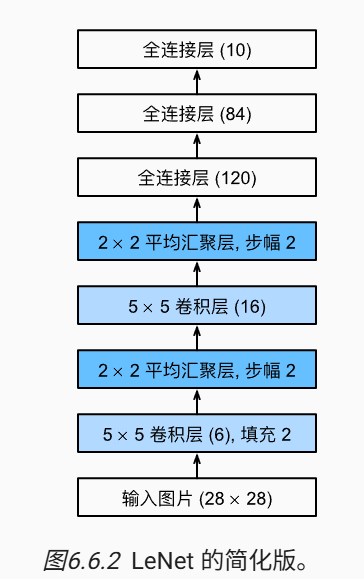

第一层卷积将1*28*28的输入图像转化为6×28×28的六张特征图，然后使用了Sigmoid()做非线性激活。然后做平均池化的下采样，降低计算量，带来一定的局部平移不敏感性，得到6×14×14的特征图。再做第二次卷积，得到16×10×10的特征图，本质上是把上一次卷积得到的低级特征组合起来，这种层次化特征学习是CNN的核心之一。再通过平均池化下采样得到16×5×5的特征图。再通过Flatten层和全连接层做分类器，送至输出。下面的一小段代码展示了每个层对数据维度尺寸的影响。

In [ ]:
# @title
import torch
from torch import nn
pip install d2l
#from d2l import torch as d2l

net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10))
X = torch.rand(size=(1, 1, 28, 28), dtype=torch.float32)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape: \t',X.shape)

Conv2d output shape: 	 torch.Size([1, 6, 28, 28])
Sigmoid output shape: 	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape: 	 torch.Size([1, 6, 14, 14])
Conv2d output shape: 	 torch.Size([1, 16, 10, 10])
Sigmoid output shape: 	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape: 	 torch.Size([1, 16, 5, 5])
Flatten output shape: 	 torch.Size([1, 400])
Linear output shape: 	 torch.Size([1, 120])
Sigmoid output shape: 	 torch.Size([1, 120])
Linear output shape: 	 torch.Size([1, 84])
Sigmoid output shape: 	 torch.Size([1, 84])
Linear output shape: 	 torch.Size([1, 10])


下面是一个训练LetNet网络，考察其在FashionMNIST数据集上的表现。

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 206kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.81MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.0MB/s]


training on cuda
epoch  1: loss 2.322, train acc 0.102, test acc 0.100
epoch  2: loss 1.587, train acc 0.380, test acc 0.509
epoch  3: loss 0.868, train acc 0.658, test acc 0.645
epoch  4: loss 0.709, train acc 0.720, test acc 0.737
epoch  5: loss 0.635, train acc 0.751, test acc 0.752
epoch  6: loss 0.580, train acc 0.777, test acc 0.752
epoch  7: loss 0.538, train acc 0.794, test acc 0.747
epoch  8: loss 0.505, train acc 0.809, test acc 0.785
epoch  9: loss 0.476, train acc 0.821, test acc 0.776
epoch 10: loss 0.460, train acc 0.830, test acc 0.807

loss 0.460, train acc 0.830, test acc 0.807
7314.7 examples/sec on cuda


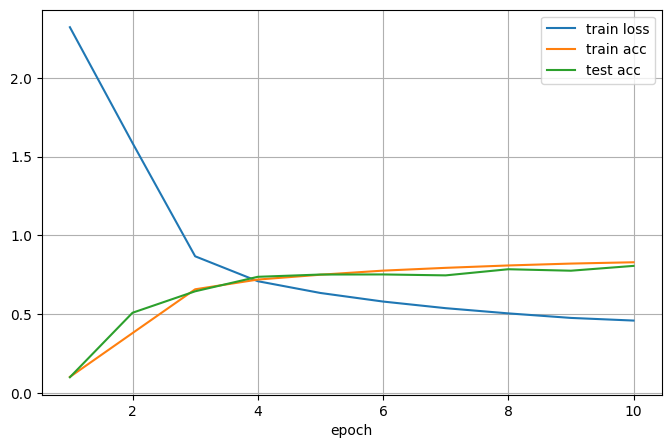

In [1]:
# @title
import time
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


# =========================
# 1. LeNet 网络结构
# =========================
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2),
    nn.Sigmoid(),

    nn.AvgPool2d(kernel_size=2, stride=2),

    nn.Conv2d(6, 16, kernel_size=5),
    nn.Sigmoid(),

    nn.AvgPool2d(kernel_size=2, stride=2),

    nn.Flatten(),

    nn.Linear(16 * 5 * 5, 120),
    nn.Sigmoid(),

    nn.Linear(120, 84),
    nn.Sigmoid(),

    nn.Linear(84, 10)
)


# =========================
# 2. 加载 Fashion-MNIST
# =========================
batch_size = 256

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

train_iter = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_iter = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


# =========================
# 3. 计算分类正确数量
# =========================
def accuracy(y_hat, y):
    """
    返回一个 batch 中预测正确的样本数量
    """
    if y_hat.ndim > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(dim=1)

    correct = (y_hat == y).float().sum()

    return correct.item()


# =========================
# 4. 在 GPU / CPU 上评估模型准确率
# =========================
def evaluate_accuracy_gpu(net, data_iter, device=None):
    """
    使用 GPU 或 CPU 计算模型在数据集上的准确率
    """

    if device is None:
        device = next(net.parameters()).device

    net.eval()

    correct_num = 0
    total_num = 0

    with torch.no_grad():

        for X, y in data_iter:

            X = X.to(device)
            y = y.to(device)

            y_hat = net(X)

            correct_num += accuracy(y_hat, y)
            total_num += y.numel()

    return correct_num / total_num


# =========================
# 5. 训练函数
# =========================
def train_ch6(
    net,
    train_iter,
    test_iter,
    num_epochs,
    lr,
    device
):

    # Xavier 初始化
    def init_weights(m):

        if type(m) == nn.Linear or type(m) == nn.Conv2d:

            nn.init.xavier_uniform_(m.weight)

    net.apply(init_weights)

    print("training on", device)

    net.to(device)

    # 优化器保持和 D2L 一致
    optimizer = torch.optim.SGD(
        net.parameters(),
        lr=lr
    )

    # 损失函数保持不变
    loss = nn.CrossEntropyLoss()

    # 用来画图
    train_loss_history = []
    train_acc_history = []
    test_acc_history = []

    total_start_time = time.time()

    for epoch in range(num_epochs):

        net.train()

        # 当前 epoch 的累计量
        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for X, y in train_iter:

            X = X.to(device)
            y = y.to(device)

            # -----------------
            # 前向传播
            # -----------------
            y_hat = net(X)

            l = loss(y_hat, y)

            # -----------------
            # 反向传播
            # -----------------
            optimizer.zero_grad()

            l.backward()

            optimizer.step()

            # -----------------
            # 统计
            # -----------------
            with torch.no_grad():

                batch_size_current = X.shape[0]

                total_loss += (
                    l.item()
                    * batch_size_current
                )

                total_correct += accuracy(
                    y_hat,
                    y
                )

                total_samples += batch_size_current

        # 一个 epoch 结束
        train_l = (
            total_loss
            / total_samples
        )

        train_acc = (
            total_correct
            / total_samples
        )

        test_acc = evaluate_accuracy_gpu(
            net,
            test_iter,
            device
        )

        train_loss_history.append(
            train_l
        )

        train_acc_history.append(
            train_acc
        )

        test_acc_history.append(
            test_acc
        )

        print(
            f"epoch {epoch + 1:2d}: "
            f"loss {train_l:.3f}, "
            f"train acc {train_acc:.3f}, "
            f"test acc {test_acc:.3f}"
        )

    total_time = (
        time.time()
        - total_start_time
    )

    print()

    print(
        f"loss {train_l:.3f}, "
        f"train acc {train_acc:.3f}, "
        f"test acc {test_acc:.3f}"
    )

    print(
        f"{len(train_dataset) * num_epochs / total_time:.1f} "
        f"examples/sec on {device}"
    )

    # =========================
    # 绘制训练曲线
    # =========================
    epochs = range(
        1,
        num_epochs + 1
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        train_loss_history,
        label="train loss"
    )

    plt.plot(
        epochs,
        train_acc_history,
        label="train acc"
    )

    plt.plot(
        epochs,
        test_acc_history,
        label="test acc"
    )

    plt.xlabel("epoch")

    plt.legend()

    plt.grid()

    plt.show()


# =========================
# 6. 选择 GPU / CPU
# =========================
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

lr = 0.9
num_epochs = 10


# =========================
# 7. 开始训练
# =========================
train_ch6(
    net,
    train_iter,
    test_iter,
    num_epochs,
    lr,
    device
)

我们尝试把平均池化改成最大池化，考察其性能变化




training on cuda
epoch  1: loss 2.320, train acc 0.102, test acc 0.100
epoch  2: loss 1.792, train acc 0.310, test acc 0.559
epoch  3: loss 0.898, train acc 0.643, test acc 0.721
epoch  4: loss 0.694, train acc 0.728, test acc 0.701
epoch  5: loss 0.618, train acc 0.758, test acc 0.755
epoch  6: loss 0.567, train acc 0.780, test acc 0.764
epoch  7: loss 0.524, train acc 0.797, test acc 0.797
epoch  8: loss 0.482, train acc 0.817, test acc 0.792
epoch  9: loss 0.454, train acc 0.830, test acc 0.785
epoch 10: loss 0.425, train acc 0.842, test acc 0.806

loss 0.425, train acc 0.842, test acc 0.806
7565.3 examples/sec on cuda


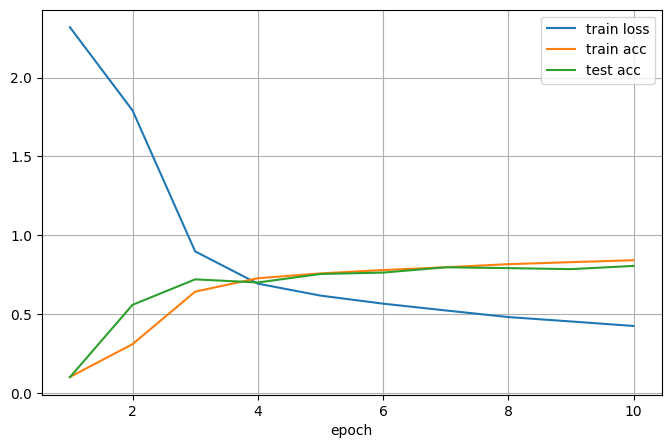

In [3]:
# @title
import time
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


# =========================
# 1. LeNet 网络结构
# =========================
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2),
    nn.Sigmoid(),

    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(6, 16, kernel_size=5),
    nn.Sigmoid(),

    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),

    nn.Linear(16 * 5 * 5, 120),
    nn.Sigmoid(),

    nn.Linear(120, 84),
    nn.Sigmoid(),

    nn.Linear(84, 10)
)


# =========================
# 2. 加载 Fashion-MNIST
# =========================
batch_size = 256

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

train_iter = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_iter = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


# =========================
# 3. 计算分类正确数量
# =========================
def accuracy(y_hat, y):
    """
    返回一个 batch 中预测正确的样本数量
    """
    if y_hat.ndim > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(dim=1)

    correct = (y_hat == y).float().sum()

    return correct.item()


# =========================
# 4. 在 GPU / CPU 上评估模型准确率
# =========================
def evaluate_accuracy_gpu(net, data_iter, device=None):
    """
    使用 GPU 或 CPU 计算模型在数据集上的准确率
    """

    if device is None:
        device = next(net.parameters()).device

    net.eval()

    correct_num = 0
    total_num = 0

    with torch.no_grad():

        for X, y in data_iter:

            X = X.to(device)
            y = y.to(device)

            y_hat = net(X)

            correct_num += accuracy(y_hat, y)
            total_num += y.numel()

    return correct_num / total_num


# =========================
# 5. 训练函数
# =========================
def train_ch6(
    net,
    train_iter,
    test_iter,
    num_epochs,
    lr,
    device
):

    # Xavier 初始化
    def init_weights(m):

        if type(m) == nn.Linear or type(m) == nn.Conv2d:

            nn.init.xavier_uniform_(m.weight)

    net.apply(init_weights)

    print("training on", device)

    net.to(device)

    # 优化器保持和 D2L 一致
    optimizer = torch.optim.SGD(
        net.parameters(),
        lr=lr
    )

    # 损失函数保持不变
    loss = nn.CrossEntropyLoss()

    # 用来画图
    train_loss_history = []
    train_acc_history = []
    test_acc_history = []

    total_start_time = time.time()

    for epoch in range(num_epochs):

        net.train()

        # 当前 epoch 的累计量
        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for X, y in train_iter:

            X = X.to(device)
            y = y.to(device)

            # -----------------
            # 前向传播
            # -----------------
            y_hat = net(X)

            l = loss(y_hat, y)

            # -----------------
            # 反向传播
            # -----------------
            optimizer.zero_grad()

            l.backward()

            optimizer.step()

            # -----------------
            # 统计
            # -----------------
            with torch.no_grad():

                batch_size_current = X.shape[0]

                total_loss += (
                    l.item()
                    * batch_size_current
                )

                total_correct += accuracy(
                    y_hat,
                    y
                )

                total_samples += batch_size_current

        # 一个 epoch 结束
        train_l = (
            total_loss
            / total_samples
        )

        train_acc = (
            total_correct
            / total_samples
        )

        test_acc = evaluate_accuracy_gpu(
            net,
            test_iter,
            device
        )

        train_loss_history.append(
            train_l
        )

        train_acc_history.append(
            train_acc
        )

        test_acc_history.append(
            test_acc
        )

        print(
            f"epoch {epoch + 1:2d}: "
            f"loss {train_l:.3f}, "
            f"train acc {train_acc:.3f}, "
            f"test acc {test_acc:.3f}"
        )

    total_time = (
        time.time()
        - total_start_time
    )

    print()

    print(
        f"loss {train_l:.3f}, "
        f"train acc {train_acc:.3f}, "
        f"test acc {test_acc:.3f}"
    )

    print(
        f"{len(train_dataset) * num_epochs / total_time:.1f} "
        f"examples/sec on {device}"
    )

    # =========================
    # 绘制训练曲线
    # =========================
    epochs = range(
        1,
        num_epochs + 1
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        train_loss_history,
        label="train loss"
    )

    plt.plot(
        epochs,
        train_acc_history,
        label="train acc"
    )

    plt.plot(
        epochs,
        test_acc_history,
        label="test acc"
    )

    plt.xlabel("epoch")

    plt.legend()

    plt.grid()

    plt.show()


# =========================
# 6. 选择 GPU / CPU
# =========================
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

lr = 0.9
num_epochs = 10


# =========================
# 7. 开始训练
# =========================
train_ch6(
    net,
    train_iter,
    test_iter,
    num_epochs,
    lr,
    device
)

改成最大池化后准确率几乎不变，这是说得通的，因为池化本质上是提供一个廉价的下采样操作，只是利用先验结构不同。这里池化核不大，且在Fashion-MNIST 这种识别任务中，局部最强响应通常很有价值，因此两种池化方式效果接近是很合理的结果。

##尝试修改优化网络
###我们先修改激活函数为ReLU，将卷积核缩小为3×3，将学习率从原来的0.9缩小为0.5，其余的结构没有变化，仅在一些需要对齐的参数上做了必要的修改。

training on cuda
epoch  1: loss 0.832, train acc 0.699, test acc 0.812
epoch  2: loss 0.463, train acc 0.825, test acc 0.838
epoch  3: loss 0.404, train acc 0.848, test acc 0.841
epoch  4: loss 0.368, train acc 0.862, test acc 0.852
epoch  5: loss 0.346, train acc 0.872, test acc 0.806
epoch  6: loss 0.321, train acc 0.880, test acc 0.829
epoch  7: loss 0.309, train acc 0.884, test acc 0.861
epoch  8: loss 0.290, train acc 0.891, test acc 0.873
epoch  9: loss 0.277, train acc 0.895, test acc 0.880
epoch 10: loss 0.267, train acc 0.900, test acc 0.863
epoch 11: loss 0.258, train acc 0.902, test acc 0.868
epoch 12: loss 0.251, train acc 0.905, test acc 0.873
epoch 13: loss 0.242, train acc 0.908, test acc 0.891
epoch 14: loss 0.233, train acc 0.912, test acc 0.875
epoch 15: loss 0.227, train acc 0.913, test acc 0.877
epoch 16: loss 0.219, train acc 0.917, test acc 0.884
epoch 17: loss 0.212, train acc 0.920, test acc 0.888
epoch 18: loss 0.206, train acc 0.922, test acc 0.891
epoch 19: l

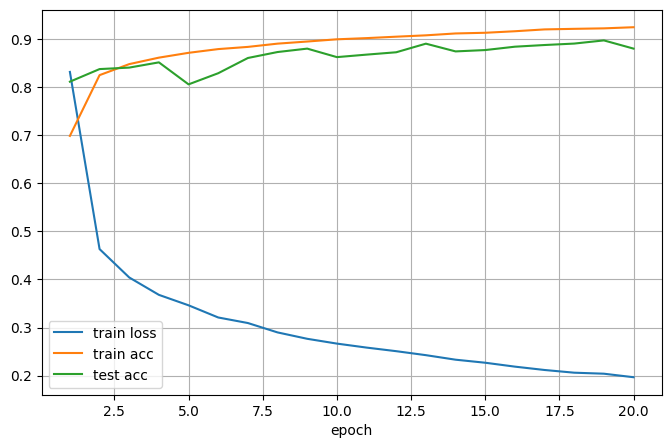

In [5]:
# @title
import time
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


# =========================
# 1. 改进后的 LeNet
# =========================
net = nn.Sequential(

    # 输入: 1 × 28 × 28
    # 输出: 6 × 28 × 28
    nn.Conv2d(
        in_channels=1,
        out_channels=6,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),

    # 6 × 28 × 28 → 6 × 14 × 14
    nn.AvgPool2d(
        kernel_size=2,
        stride=2
    ),

    # 6 × 14 × 14 → 16 × 12 × 12
    nn.Conv2d(
        in_channels=6,
        out_channels=16,
        kernel_size=3
    ),
    nn.ReLU(),

    # 16 × 12 × 12 → 16 × 6 × 6
    nn.AvgPool2d(
        kernel_size=2,
        stride=2
    ),

    # 16 × 6 × 6 → 576
    nn.Flatten(),

    # 576 → 120
    nn.Linear(16 * 6 * 6, 120),
    nn.ReLU(),

    # 120 → 84
    nn.Linear(120, 84),
    nn.ReLU(),

    # 84 → 10
    nn.Linear(84, 10)
)


# =========================
# 2. Fashion-MNIST
# =========================
batch_size = 256

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

train_iter = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_iter = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


# =========================
# 3. 准确率
# =========================
def accuracy(y_hat, y):

    if y_hat.ndim > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(dim=1)

    return (y_hat == y).float().sum().item()


# =========================
# 4. 测试集准确率
# =========================
def evaluate_accuracy_gpu(net, data_iter, device=None):

    if device is None:
        device = next(net.parameters()).device

    net.eval()

    correct_num = 0
    total_num = 0

    with torch.no_grad():

        for X, y in data_iter:

            X = X.to(device)
            y = y.to(device)

            y_hat = net(X)

            correct_num += accuracy(y_hat, y)
            total_num += y.numel()

    return correct_num / total_num


# =========================
# 5. 训练
# =========================
def train_ch6(
    net,
    train_iter,
    test_iter,
    num_epochs,
    lr,
    device
):

    # ReLU 更适合 Kaiming 初始化
    def init_weights(m):

        if isinstance(m, (nn.Linear, nn.Conv2d)):

            nn.init.kaiming_uniform_(
                m.weight,
                nonlinearity="relu"
            )

            if m.bias is not None:
                nn.init.zeros_(m.bias)

    net.apply(init_weights)

    print("training on", device)

    net.to(device)

    optimizer = torch.optim.SGD(
        net.parameters(),
        lr=lr
    )

    loss = nn.CrossEntropyLoss()

    train_loss_history = []
    train_acc_history = []
    test_acc_history = []

    total_start_time = time.time()

    for epoch in range(num_epochs):

        net.train()

        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for X, y in train_iter:

            X = X.to(device)
            y = y.to(device)

            # 前向传播
            y_hat = net(X)

            l = loss(y_hat, y)

            # 清空梯度
            optimizer.zero_grad()

            # 反向传播
            l.backward()

            # 更新参数
            optimizer.step()

            # 统计
            with torch.no_grad():

                batch_size_current = X.shape[0]

                total_loss += (
                    l.item()
                    * batch_size_current
                )

                total_correct += accuracy(
                    y_hat,
                    y
                )

                total_samples += batch_size_current

        # 当前 epoch 的训练结果
        train_l = (
            total_loss
            / total_samples
        )

        train_acc = (
            total_correct
            / total_samples
        )

        test_acc = evaluate_accuracy_gpu(
            net,
            test_iter,
            device
        )

        train_loss_history.append(
            train_l
        )

        train_acc_history.append(
            train_acc
        )

        test_acc_history.append(
            test_acc
        )

        print(
            f"epoch {epoch + 1:2d}: "
            f"loss {train_l:.3f}, "
            f"train acc {train_acc:.3f}, "
            f"test acc {test_acc:.3f}"
        )

    total_time = (
        time.time()
        - total_start_time
    )

    print()

    print(
        f"loss {train_l:.3f}, "
        f"train acc {train_acc:.3f}, "
        f"test acc {test_acc:.3f}"
    )

    print(
        f"{len(train_dataset) * num_epochs / total_time:.1f} "
        f"examples/sec on {device}"
    )

    # =========================
    # 绘制训练曲线
    # =========================
    epochs = range(
        1,
        num_epochs + 1
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        train_loss_history,
        label="train loss"
    )

    plt.plot(
        epochs,
        train_acc_history,
        label="train acc"
    )

    plt.plot(
        epochs,
        test_acc_history,
        label="test acc"
    )

    plt.xlabel("epoch")
    plt.legend()
    plt.grid()
    plt.show()


# =========================
# 6. 设备
# =========================
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# =========================
# 7. 训练参数
# =========================

# ReLU 后不建议继续直接使用原来的 0.9
# 先使用更稳妥的 0.5
lr = 0.5

num_epochs = 20


# =========================
# 8. 开始训练
# =========================
train_ch6(
    net,
    train_iter,
    test_iter,
    num_epochs,
    lr,
    device
)

我们在此基础上再加一层卷积层，并把学习率降到0.1，观察性能的变化

In [ ]:
# @title
import time
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


# =========================
# 1. 改进后的 LeNet
# =========================
net = nn.Sequential(

    # 输入: 1 × 28 × 28
    # 输出: 6 × 28 × 28
    nn.Conv2d(
        in_channels=1,
        out_channels=6,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),

    # 6 × 28 × 28 → 6 × 14 × 14
    nn.AvgPool2d(
        kernel_size=2,
        stride=2
    ),

    # 6 × 14 × 14 → 16 × 12 × 12
    nn.Conv2d(
        in_channels=6,
        out_channels=16,
        kernel_size=3
    ),
    nn.ReLU(),

    # =========================
    # 新增卷积层
    # =========================
    # padding=1，因此尺寸保持不变
    # 16 × 12 × 12 → 16 × 12 × 12
    nn.Conv2d(
        in_channels=16,
        out_channels=16,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),

    # 16 × 12 × 12 → 16 × 6 × 6
    nn.AvgPool2d(
        kernel_size=2,
        stride=2
    ),

    # 16 × 6 × 6 → 576
    nn.Flatten(),

    # 576 → 120
    nn.Linear(16 * 6 * 6, 120),
    nn.ReLU(),

    # 120 → 84
    nn.Linear(120, 84),
    nn.ReLU(),

    # 84 → 10
    nn.Linear(84, 10)
)

# =========================
# 2. Fashion-MNIST
# =========================
batch_size = 256

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

train_iter = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_iter = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


# =========================
# 3. 准确率
# =========================
def accuracy(y_hat, y):

    if y_hat.ndim > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(dim=1)

    return (y_hat == y).float().sum().item()


# =========================
# 4. 测试集准确率
# =========================
def evaluate_accuracy_gpu(net, data_iter, device=None):

    if device is None:
        device = next(net.parameters()).device

    net.eval()

    correct_num = 0
    total_num = 0

    with torch.no_grad():

        for X, y in data_iter:

            X = X.to(device)
            y = y.to(device)

            y_hat = net(X)

            correct_num += accuracy(y_hat, y)
            total_num += y.numel()

    return correct_num / total_num


# =========================
# 5. 训练
# =========================
def train_ch6(
    net,
    train_iter,
    test_iter,
    num_epochs,
    lr,
    device
):

    # ReLU 更适合 Kaiming 初始化
    def init_weights(m):

        if isinstance(m, (nn.Linear, nn.Conv2d)):

            nn.init.kaiming_uniform_(
                m.weight,
                nonlinearity="relu"
            )

            if m.bias is not None:
                nn.init.zeros_(m.bias)

    net.apply(init_weights)

    print("training on", device)

    net.to(device)

    optimizer = torch.optim.SGD(
        net.parameters(),
        lr=lr
    )

    loss = nn.CrossEntropyLoss()

    train_loss_history = []
    train_acc_history = []
    test_acc_history = []

    total_start_time = time.time()

    for epoch in range(num_epochs):

        net.train()

        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for X, y in train_iter:

            X = X.to(device)
            y = y.to(device)

            # 前向传播
            y_hat = net(X)

            l = loss(y_hat, y)

            # 清空梯度
            optimizer.zero_grad()

            # 反向传播
            l.backward()

            # 更新参数
            optimizer.step()

            # 统计
            with torch.no_grad():

                batch_size_current = X.shape[0]

                total_loss += (
                    l.item()
                    * batch_size_current
                )

                total_correct += accuracy(
                    y_hat,
                    y
                )

                total_samples += batch_size_current

        # 当前 epoch 的训练结果
        train_l = (
            total_loss
            / total_samples
        )

        train_acc = (
            total_correct
            / total_samples
        )

        test_acc = evaluate_accuracy_gpu(
            net,
            test_iter,
            device
        )

        train_loss_history.append(
            train_l
        )

        train_acc_history.append(
            train_acc
        )

        test_acc_history.append(
            test_acc
        )

        print(
            f"epoch {epoch + 1:2d}: "
            f"loss {train_l:.3f}, "
            f"train acc {train_acc:.3f}, "
            f"test acc {test_acc:.3f}"
        )

    total_time = (
        time.time()
        - total_start_time
    )

    print()

    print(
        f"loss {train_l:.3f}, "
        f"train acc {train_acc:.3f}, "
        f"test acc {test_acc:.3f}"
    )

    print(
        f"{len(train_dataset) * num_epochs / total_time:.1f} "
        f"examples/sec on {device}"
    )

    # =========================
    # 绘制训练曲线
    # =========================
    epochs = range(
        1,
        num_epochs + 1
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        train_loss_history,
        label="train loss"
    )

    plt.plot(
        epochs,
        train_acc_history,
        label="train acc"
    )

    plt.plot(
        epochs,
        test_acc_history,
        label="test acc"
    )

    plt.xlabel("epoch")
    plt.legend()
    plt.grid()
    plt.show()


# =========================
# 6. 设备
# =========================
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# =========================
# 7. 训练参数
# =========================

# ReLU 后不建议继续直接使用原来的 0.9
# 先使用更稳妥的 0.5
lr = 0.5

num_epochs = 20


# =========================
# 8. 开始训练
# =========================
train_ch6(
    net,
    train_iter,
    test_iter,
    num_epochs,
    lr,
    device
)